## 1. Setup and Imports

In [1]:
from sage.all import *
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/bitcoin_timeseries.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df.set_index('timestamp', inplace=True)


## 2. Select Subset of Data for Modeling

In [4]:
# Focus on the last 7 days, sampled hourly
last_timestamp = df.index.max()
recent = df.loc[df.index >= last_timestamp - pd.Timedelta(days=7)]
df_model = recent.resample('1h').mean().dropna()
df_model = df_model.reset_index()

# Convert timestamps to numeric
x_data = [(t - df_model['timestamp'][0]).total_seconds() / 3600 for t in df_model['timestamp']]
y_data = list(df_model['price_usd'])

print(f"✅ Sampled {len(x_data)} data points")


✅ Sampled 153 data points


## 3. Symbolic Polynomial Fit (Degree 3)

In [6]:
x, a0, a1, a2, a3 = var('x a0 a1 a2 a3')
model = a0 + a1*x + a2*x**2 + a3*x**3

# Construct system of equations using sampled points
eqns = [model.subs(x=x_data[i]) == y_data[i] for i in range(4)]

# Solve symbolically
solution = solve(eqns, a0, a1, a2, a3)
model_fitted = model.subs(solution)

model_fitted

-8729/680*x^3 + 1453/17*x^2 - 116691/680*x + 1756618/17

## 4. Plot Fitted Polynomial vs Actual Data

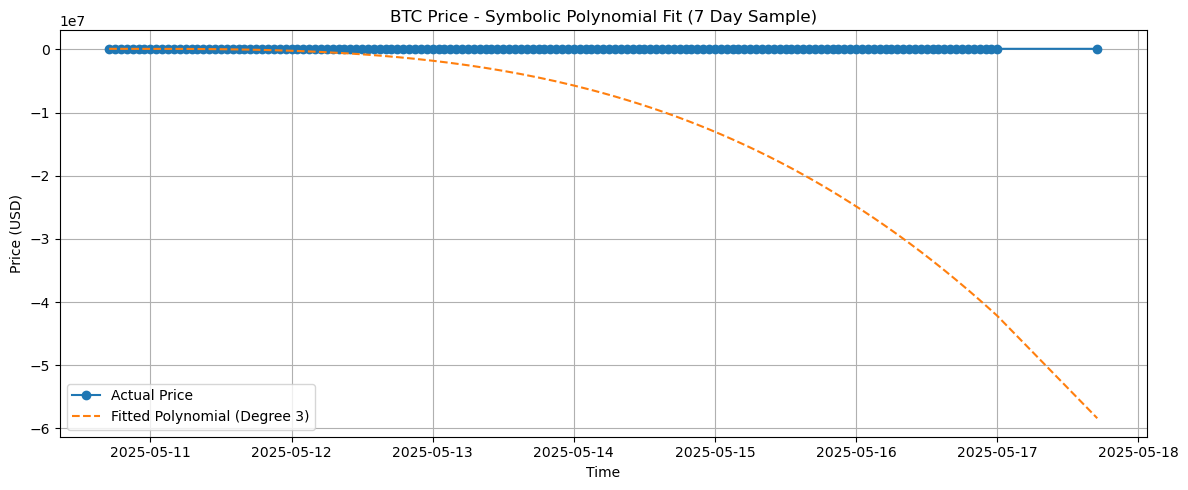

In [7]:
# Evaluate fitted polynomial
f = lambda t: float(model_fitted.subs(x=t))
y_fit = [f(t) for t in x_data]

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df_model['timestamp'], y_data, label='Actual Price', marker='o')
plt.plot(df_model['timestamp'], y_fit, label='Fitted Polynomial (Degree 3)', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.title("BTC Price - Symbolic Polynomial Fit (7 Day Sample)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../reports/symbolic_polynomial_fit.png')
plt.show()
